In [75]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [76]:
import os
import glob
import numpy as np

folder = "medición_1"

I = []
W_val = []
W_err = []

for filepath in glob.glob(os.path.join(folder, "*.txt")):
    # parse current from filename, e.g. "2.20.txt" -> 2.20
    fname = os.path.splitext(os.path.basename(filepath))[0]
    current = float(fname.replace(",", "."))

    values = []
    with open(filepath, encoding="utf-8") as f:
        next(f)  # skip header line
        next(f)
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            val_str = parts[1].strip().replace(",", ".")
            values.append(float(val_str))

    values = np.array(values)
    vmin, vmax = values.min(), values.max()
    I.append(current)
    W_val.append(np.mean(values))
    W_err.append(np.std(values))

#    I.append(current)
#    W_val.append((vmax + vmin) / 2)
#    W_err.append((vmax - vmin) / 2)


I = np.array(I)
W_val = np.array(W_val)
W_err = np.array(W_err)

<ErrorbarContainer object of 3 artists>

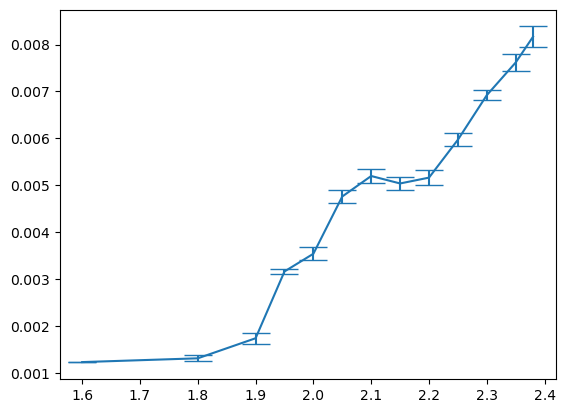

In [77]:
plt.errorbar(I,W_val,W_err,capsize=10)


In [78]:

folder = "medición_1_fondo"

I_bg = []
W_val_bg = []
W_err_bg = []

for filepath in glob.glob(os.path.join(folder, "*.txt")):
    # parse current from filename, e.g. "2.20.txt" -> 2.20
    fname = os.path.splitext(os.path.basename(filepath))[0]
    current = float(fname.replace(",", "."))

    values = []
    with open(filepath, encoding="utf-8") as f:
        next(f)  # skip header line
        next(f)
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            val_str = parts[1].strip().replace(",", ".")
            values.append(float(val_str))

    values = np.array(values)
    vmin, vmax = values.min(), values.max()

    I_bg.append(current)
    W_val_bg.append(np.mean(values))
    W_err_bg.append(np.std(values))

#    I_bg.append(current)
#    W_val_bg.append((vmax + vmin) / 2)
#    W_err_bg.append((vmax - vmin) / 2)



I_bg = np.array(I_bg)
W_val_bg = np.array(W_val_bg)
W_err_bg = np.array(W_err_bg)

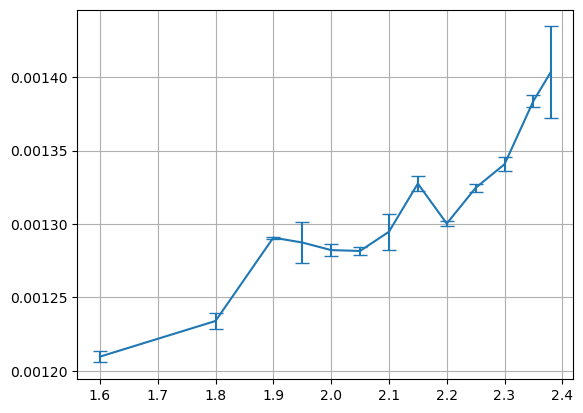

In [79]:
plt.errorbar(I_bg,W_val_bg,W_err_bg,capsize=5)
plt.grid()

<ErrorbarContainer object of 3 artists>

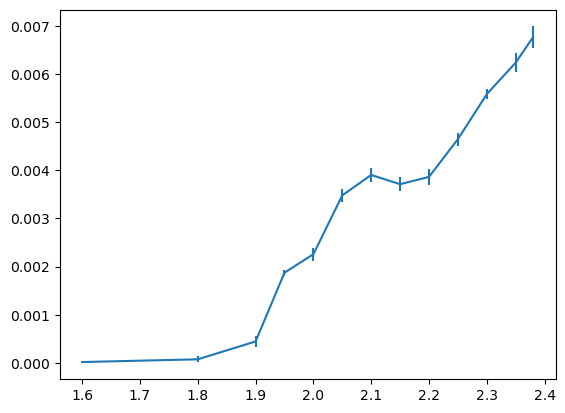

In [80]:
plt.errorbar(I, W_val - W_val_bg,np.sqrt(W_err_bg**2 + W_err**2))